In [1]:
import numpy as np 
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

Iris dataset is one of the earliest datasets used in classification literature. 
This is one of the earliest datasets used in the literature on classification methods and widely used 
in statistics and machine learning. The data set contains 3 classes of 50 instances each, where each 
class refers to a type of iris plant. One class is linearly separable from the other 2; 
the latter are not linearly separable from each other.

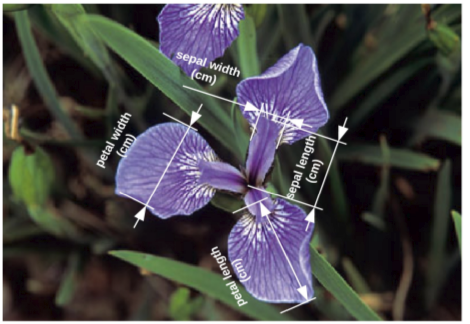


In [5]:
#Caveat - Original Dataset from UCI is in order, so use shuffle
# Use Shuffled_Iris = Iris.sample(frac=1).reset_index(drop=True)
Iris = pd.read_csv('Iris.csv')

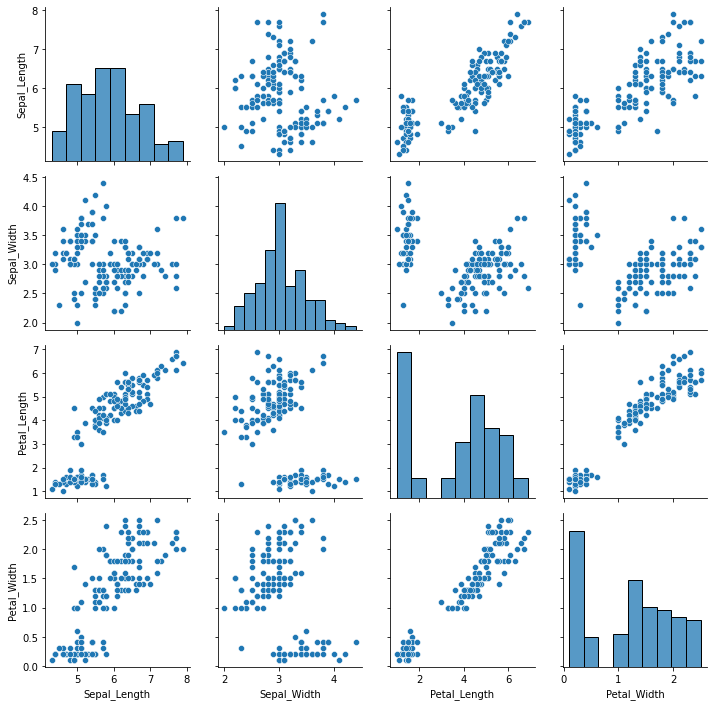

In [12]:
#VisualisationI
Iris_Vis = sns.PairGrid(Iris)
Iris_Vis.map_diag(sns.histplot)
Iris_Vis.map_offdiag(sns.scatterplot)
Iris_Vis.add_legend()

In [14]:
#Percentage of each class / Iris type
Class = Iris.iloc[:,-1]
print('Percentage of Iris Setosa (Class 1) = %.3f'%(Class[Class=='Iris-setosa'].count()/Class.count()))
print('Percentage of Iris Virginica (Class 1) = %.3f'%(Class[Class=='Iris-virginica'].count()/Class.count()))
print('Percentage of Iris Versicolor (Class 1) = %.3f'%(Class[Class=='Iris-versicolor'].count()/Class.count()))

Percentage of Iris Setosa (Class 1) = 0.000
Percentage of Iris Virginica (Class 1) = 0.000
Percentage of Iris Versicolor (Class 1) = 0.000


It can be observed from the pairwise scatterplot that the Iris Setosa (blue in the plot)
is linearly separable from the other two Iris types. However, the Iris versicolor and virginica have instances
overlapping in some of the datasets dimensions: Sepal Width vs Sepal Length and Petal Width vs all features.
The distributions of the features for each Iris type confirms the above. They overlap for the sepa features, 
but the distribution of the petal features values for the Iris Setosa is quite distinct from the other two.
Since there are 150 instances in the dataset and exactly 50 instance per Iris type, it is possible that a
classification algorithm would converge towardsa local minima of 66.66% MSE where two out of the three Iris types
(classes) are correctly separated by a linear hyperplane, whilst either versicolor or virginica is assigned the 
wrong type.

# Question 2 

### (a) Load the iris dataset (5) Visualize the data and conduct statistical analysis (5) Comment on the distribution (2)

In [15]:
Features = pd.read_csv('Iris.csv')
Features.head(5)

,Sepal_Length,Sepal_Width,Petal_Length,Petal_Width
0,7.2,3.0,5.8,1.6
1,6.8,3.0,5.5,2.1
2,5.0,2.0,3.5,1.0
3,4.8,3.1,1.6,0.2
4,6.9,3.1,5.1,2.3


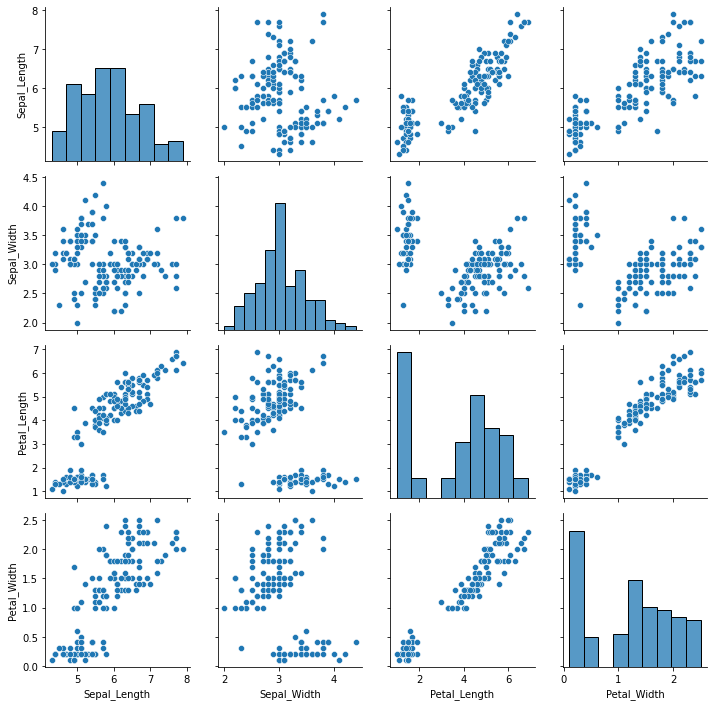

In [16]:
#VisualisationI
Iris_Vis = sns.PairGrid(Features)
Iris_Vis.map_diag(sns.histplot)
Iris_Vis.map_offdiag(sns.scatterplot)
Iris_Vis.add_legend()

In [ ]:
#Statistical Analysis - Unsure what to look at here... the histogram +kde?

In [17]:
Features.describe()

,Sepal_Length,Sepal_Width,Petal_Length,Petal_Width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


No handles with labels found to put in legend.


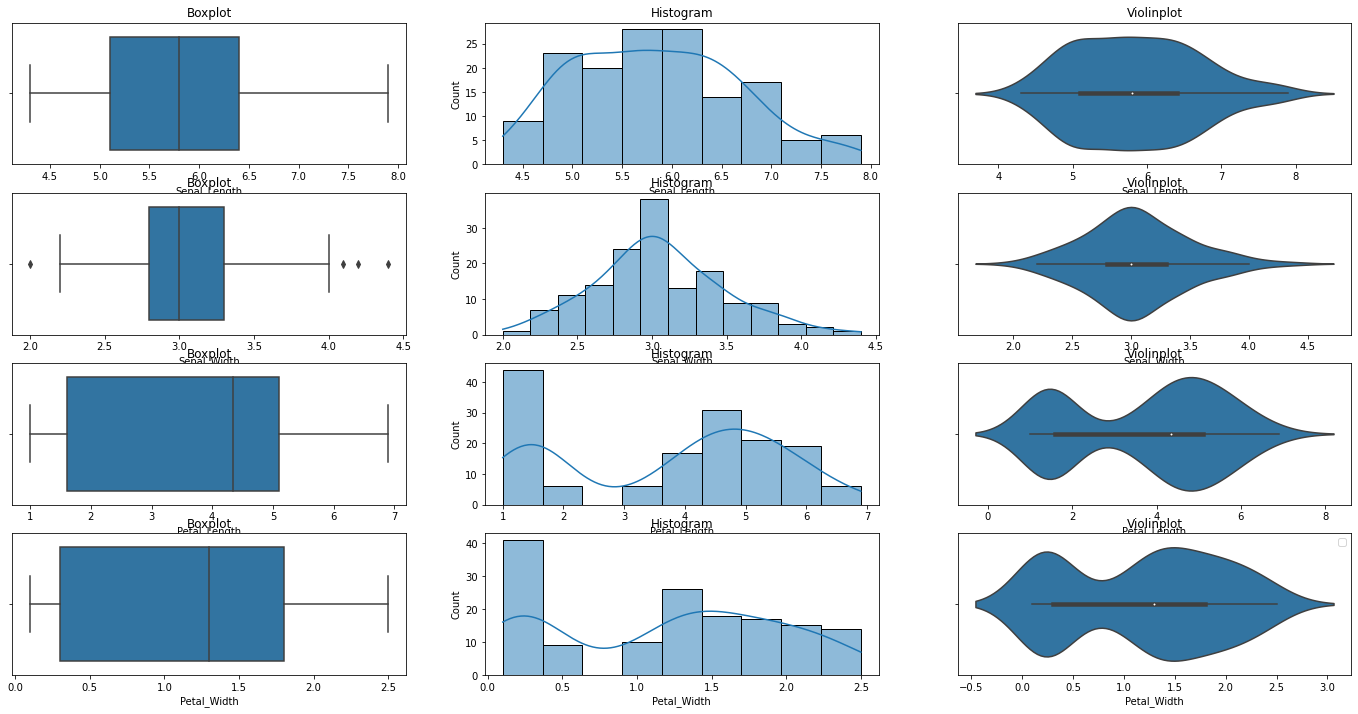

In [18]:
# Set up matplotlib figure with three subplots
f, axes = plt.subplots(4, 3, figsize=(24, 12))

# Plot the basic uni-variate figures for HP
for i in range(len(Features.columns)):
    sns.boxplot(x = Features.columns[i] , data = Features, ax = axes[i,0]).set_title("Boxplot")
    sns.histplot(x= Features.columns[i] , data = Features, kde = True, ax = axes[i,1]).set_title("Histogram")
    sns.violinplot(x= Features.columns[i] , data = Features, ax = axes[i,2]).set_title("Violinplot")
plt.legend()
#sb.boxplot(x=Features, orient = "h", ax = axes[0,0])

## Plot the basic uni-variate figures for "Attack"
#sb.boxplot(x=Features, orient = "h", ax = axes[1,0], color = 'r')
#sb.histplot(x=Features, kde = False, ax = axes[1,1], color = 'r')
#sb.violinplot(x=Features, ax = axes[1,2], color = 'r')

It can be observed from the pairwise scatterplot that the Iris dataset seems to have one set of instances that are
clearly separable from the rest of the dataset's instances. This is also observable from the histograms for
Petal Length and Petal Width. This suggests that there may be at least two differnt classes (or clusters) in this 
dataset. Mention the normal distribution of the Sepal features?

### (b) Perform K-means clustering and K-Means++. For both clustering methods, draw an elbow plot (y-axis: within sum of squares, x-axis: number of clusters) and decide the optimal number of clusters. Justify your choice. 10 + 2 + 2 marks

C:\Users\andyp\AppData\Roaming\Python\Python39\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\andyp\AppData\Roaming\Python\Python39\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\andyp\AppData\Roaming\Python\Python39\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\andyp\AppData\Roaming\Python\Python39\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: K

C:\Users\andyp\AppData\Roaming\Python\Python39\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\andyp\AppData\Roaming\Python\Python39\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\andyp\AppData\Roaming\Python\Python39\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\andyp\AppData\Roaming\Python\Python39\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: K

C:\Users\andyp\AppData\Roaming\Python\Python39\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\andyp\AppData\Roaming\Python\Python39\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\andyp\AppData\Roaming\Python\Python39\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\andyp\AppData\Roaming\Python\Python39\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: K

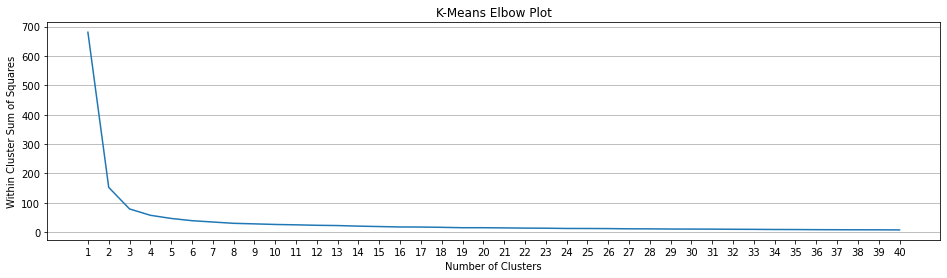

In [19]:
# Clustering for Kmeans
from sklearn.cluster import KMeans
# Elbow plot to determine optimal number of clusters

# Vary the Number of Clusters
min_clust = 1
max_clust = 40

# Compute Within Cluster Sum of Squares
within_ss = []
for num_clust in range(min_clust, max_clust+1):
    kmeans = KMeans(n_clusters = num_clust)
    kmeans.fit(Features)
    within_ss.append(kmeans.inertia_)

# Elbow Plot : Within SS vs Number of Clusters
f, axes = plt.subplots(1, 1, figsize=(16,4))
plt.title('K-Means Elbow Plot')
plt.plot(range(min_clust, max_clust+1), within_ss)
plt.xlabel('Number of Clusters')
plt.ylabel('Within Cluster Sum of Squares')
plt.xticks(np.arange(min_clust, max_clust+1, 1.0))
plt.grid(which='major', axis='y')
plt.show()

In [20]:
"""Using the Kmeans Algorithm, the optimum number of clusters seems to be 3, as this is the number of K clusters
At the 'Elbow' of the plot"""
optimum_K = 3

In [21]:
# Create Clustering Model using KMeans
kmeans = KMeans(n_clusters = optimum_K)

# Fit the Clustering Model on the Data
kmeans.fit(Features)

C:\Users\andyp\AppData\Roaming\Python\Python39\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\andyp\AppData\Roaming\Python\Python39\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


KMeans(n_clusters=3)

In [22]:
# Print the Cluster Centers
print("Features\t", 'Sepal_Length\t','Sepal_Width\t','Petal_Length\t','Petal_Width')
print()

for i, center in enumerate(kmeans.cluster_centers_):
    print("Iris_Type", i, end=":\t\t")
    for coord in center:
        print(round(coord, 2), end="\t\t")
    print()

Features	 Sepal_Length	 Sepal_Width	 Petal_Length	 Petal_Width

Iris_Type 0:		5.01		3.42		1.46		0.24		
Iris_Type 1:		5.9		2.75		4.39		1.43		
Iris_Type 2:		6.85		3.07		5.74		2.07		


<AxesSubplot:xlabel='Iris_Type', ylabel='count'>

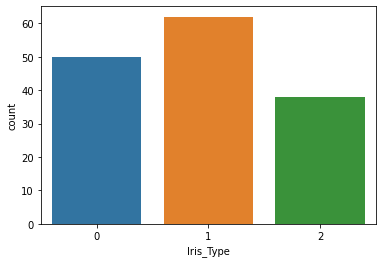

In [23]:
# Predict the Cluster Labels
labels = kmeans.predict(Features)

# Append Labels to the Data
Features_labeled = Features.copy()
Features_labeled["Iris_Type"] = pd.Categorical(labels)

# Summary of the Cluster Labels
sns.countplot(x=Features_labeled["Iris_Type"])

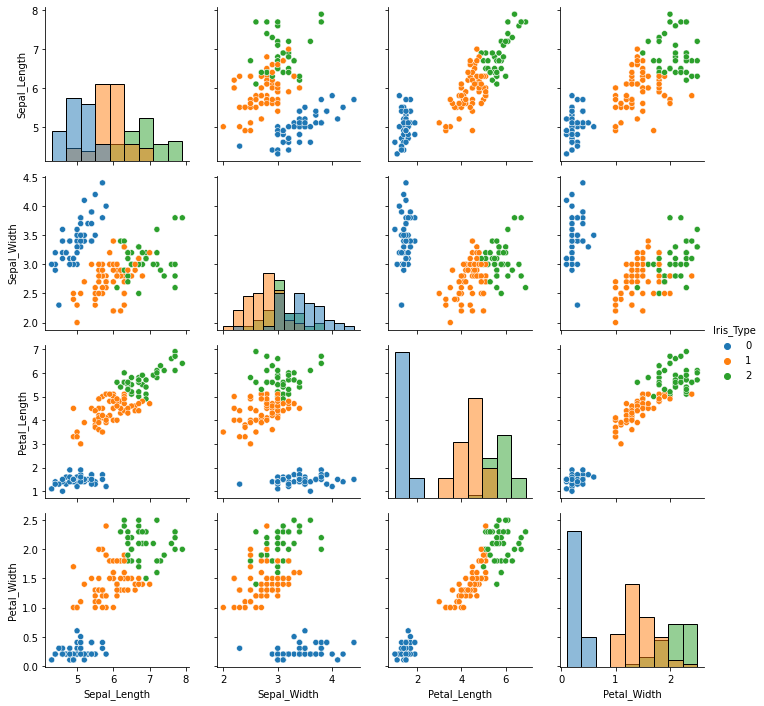

In [24]:
# Visualize the Clusters in the Data
Iris_Kmeans = sns.PairGrid(Features_labeled, hue="Iris_Type")
Iris_Kmeans.map_diag(sns.histplot)
Iris_Kmeans.map_offdiag(sns.scatterplot)
Iris_Kmeans.add_legend()

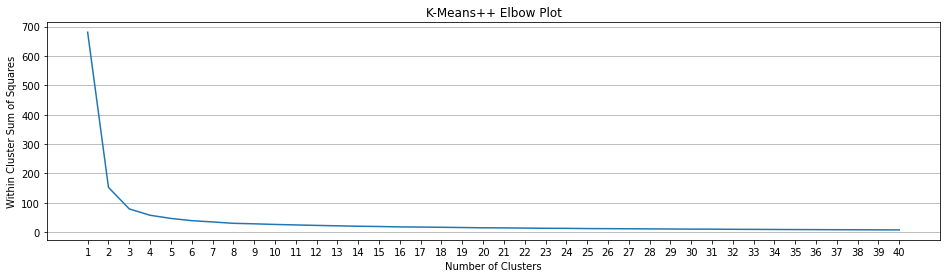

In [15]:
# Set the Initialization to KMeans++
init_algo = 'k-means++'
# Vary the Number of Clusters
min_clust = 1
max_clust = 40

# Compute Within Cluster Sum of Squares
within_ss = []
for num_clust in range(min_clust, max_clust+1):
    kmeans = KMeans(n_clusters = num_clust, init = init_algo, n_init = 20)
    kmeans.fit(Features)
    within_ss.append(kmeans.inertia_)

# Elbow Plot : Within SS vs Number of Clusters
f, axes = plt.subplots(1, 1, figsize=(16,4))
plt.title('K-Means++ Elbow Plot')
plt.plot(range(min_clust, max_clust+1), within_ss)
plt.xlabel('Number of Clusters')
plt.ylabel('Within Cluster Sum of Squares')
plt.xticks(np.arange(min_clust, max_clust+1, 1.0))
plt.grid(which='major', axis='y')
plt.show()

In [16]:
"""Using the Kmeans++ Algorithm, the optimum number of clusters seems to be 3, as this is the number of K clusters
At the 'Elbow' of the plot - This is the same as using the K-Means algoithm"""
optimum_K = 3

In [17]:
# Create Clustering Model using KMeans
kmeans = KMeans(n_clusters = optimum_K, init = init_algo, n_init = 20)                 

# Fit the Clustering Model on the Data
kmeans.fit(Features)

# Print the Cluster Centers
print("Features\t", 'Sepal_Length\t','Sepal_Width\t','Petal_Length\t','Petal_Width')
print()

for i, center in enumerate(kmeans.cluster_centers_):
    print("Cluster", i, end=":\t\t")
    for coord in center:
        print(round(coord, 2), end="\t\t")
    print()
print()

Features	 Sepal_Length	 Sepal_Width	 Petal_Length	 Petal_Width

Cluster 0:		6.85		3.07		5.74		2.07		
Cluster 1:		5.01		3.42		1.46		0.24		
Cluster 2:		5.9		2.75		4.39		1.43		



Within Cluster Sum of Squares : 78.94084142614601



<AxesSubplot:xlabel='Iris_Type', ylabel='count'>

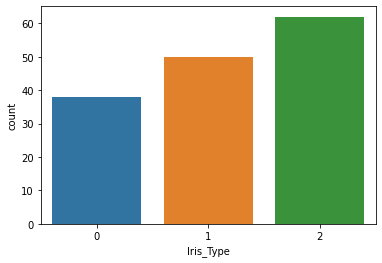

In [18]:
# Print the Within Cluster Sum of Squares
print("Within Cluster Sum of Squares :", kmeans.inertia_)
print()

# Predict the Cluster Labels
labels = kmeans.predict(Features)

# Append Labels to the Data
Features_labeled_Kplus = Features.copy()
Features_labeled_Kplus["Iris_Type"] = pd.Categorical(labels)

# Summary of the Cluster Labels
sns.countplot(x=Features_labeled_Kplus["Iris_Type"])

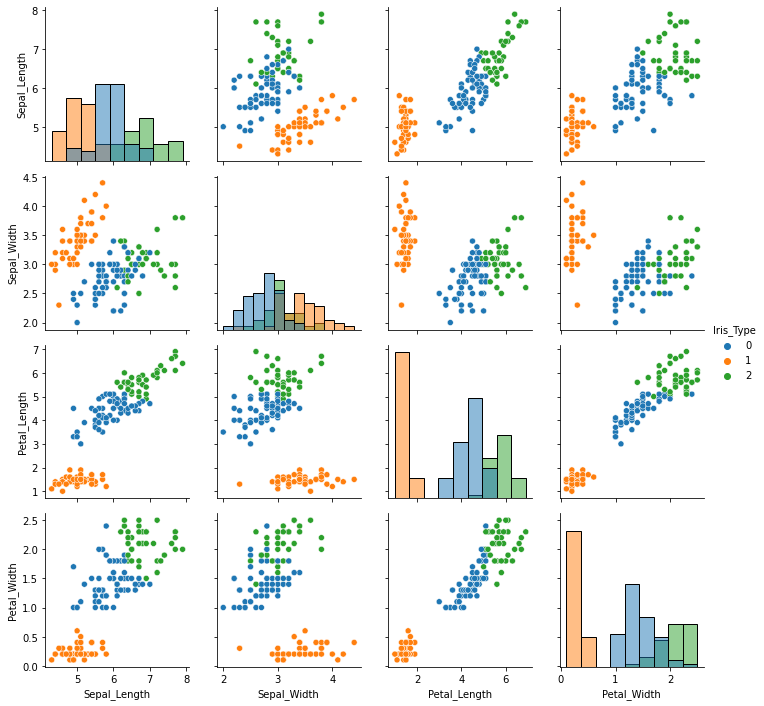

In [74]:
# Visualize the Clusters in the Data
Iris_Kmeans = sns.PairGrid(Features_labeled_Kplus, hue="Iris_Type")
Iris_Kmeans.map_diag(sns.histplot)
Iris_Kmeans.map_offdiag(sns.scatterplot)
Iris_Kmeans.add_legend()

### (c) Interpret the clusters. 5 marks

The clusters show that one type of Iris is separable from the other two using a linear hyperplane, but that
the other two Iris types have some instances with overlapping features. This means that there may be some 
misclassified Irises in the two overlapping Types, and therefore that the result of the KMeans clustering may not
be optimal. This can only be verified using the labelled dataset

### (d) Perform anomaly detection. Use 0.1A%, where A is the last digit of your student ID as contamination fraction. Use (10+A) as the number of neighbours.

In [25]:
# Import LocalOutlierFactor from sklearn.neighbors
from sklearn.neighbors import LocalOutlierFactor

# Set the Parameters for Neighborhood
num_neighbors = 19      # Number of Neighbors
cont_fraction = 0.19    # Fraction of Anomalies

# Create Anomaly Detection Model using LocalOutlierFactor
lof = LocalOutlierFactor(n_neighbors = num_neighbors, contamination = cont_fraction)

# Fit the Model on the Data and Predict Anomalies
lof.fit(Features)

LocalOutlierFactor(contamination=0.19, n_neighbors=19)

<AxesSubplot:xlabel='Anomaly', ylabel='count'>

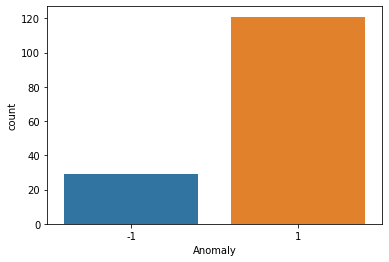

In [26]:
# Predict the Anomalies
labels = lof.fit_predict(Features)

# Append Labels to the Data
Features_labeled_outlier = Features.copy()
Features_labeled_outlier["Anomaly"] = pd.Categorical(labels)

# Summary of the Anomaly Labels
sns.countplot(x=Features_labeled_outlier["Anomaly"])

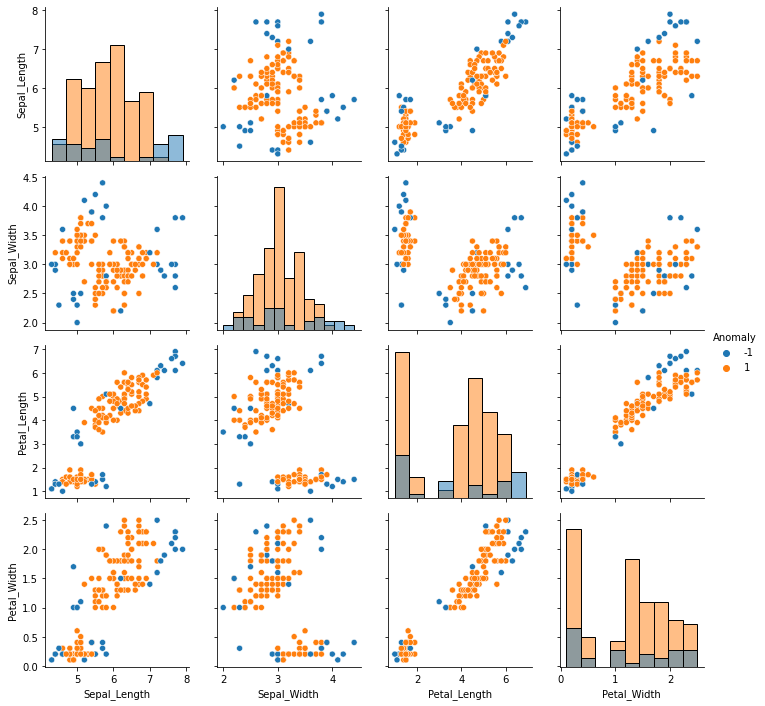

In [103]:
# Visualize the Anomalies in the Data
Iris_Outliers = sns.PairGrid(Features_labeled_outlier, vars = Features.columns.values, hue = "Anomaly")
Iris_Outliers.map_diag(sns.histplot)
Iris_Outliers.map_offdiag(sns.scatterplot)
Iris_Outliers.add_legend()

<AxesSubplot:xlabel='Petal_Width', ylabel='Anomaly'>

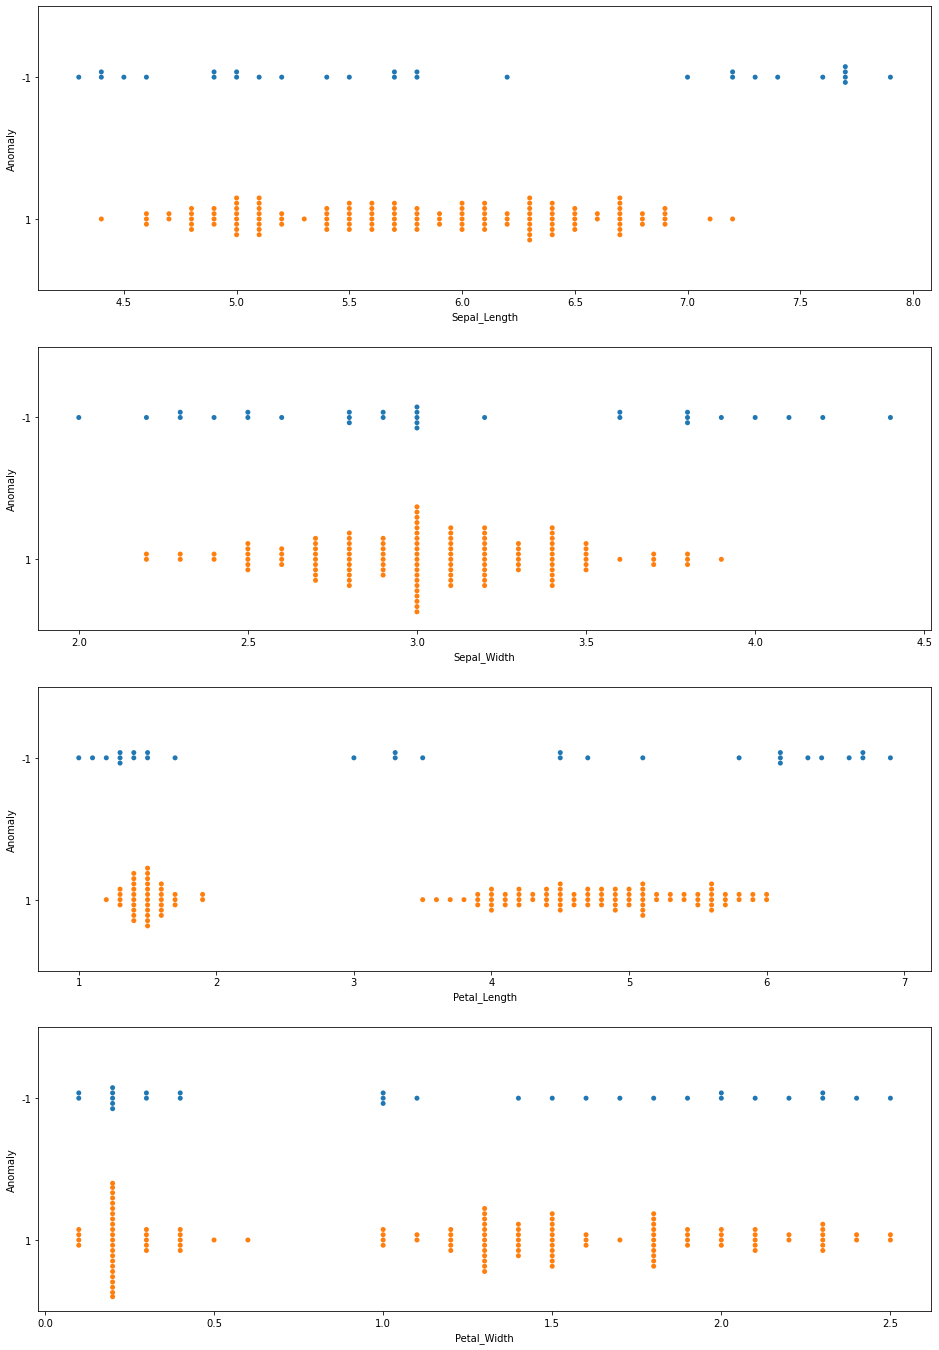

In [27]:
# Swarmplot for all Features against the Anomalies
f, axes = plt.subplots(4, 1, figsize=(16,24))
sns.swarmplot(x = 'Sepal_Length', y = 'Anomaly', data = Features_labeled_outlier, ax = axes[0])
sns.swarmplot(x = 'Sepal_Width', y = 'Anomaly', data = Features_labeled_outlier, ax = axes[1])
sns.swarmplot(x = 'Petal_Length', y = 'Anomaly', data = Features_labeled_outlier, ax = axes[2])
sns.swarmplot(x = 'Petal_Width', y = 'Anomaly', data = Features_labeled_outlier, ax = axes[3])